# TMDB - Box Office Prediction

Table of Contents
- [1. Data Loading and Preliminary Actions](#1-data-loading-and-preliminary-actions)
- [2. Feature Engineering](#2-feature-engineering)
  - [2.1 Release Date](#21-release-date)
  - [2.2 Belongs To Collection](#22-belongs-to-collection)
  - [2.3 Budget](#23-budget)
  - [2.4 Multi Label Features](#24-multi-label-features)
  - [2.5 Homepage](#25-homepage)
  - [2.7 Director](#27-director)
  - [2.8 Popularity](#28-popularity)
  - [2.9 Runtime](#29-runtime)
  - [2.10 Cross-Features](#210-cross-features)
  - [2.11 Textual Features](#211-textual-features)
  - [2.12 Feature Engineering Pipeline](#212-feature-engineering-pipeline)
- [3. Model tuning](#3-model-tuning)
  - [3.1 Dummy Regressor (Mean)](#31-dummy-regressor-mean)
  - [3.2 Dummy Regressor (Median)](#32-dummy-regressor-median)
  - [3.3 Random Forest Regressor](#33-random-forest-regressor)
  - [3.4 XGBoost Regressor](#34-xgboost-regressor)
  - [3.5 LightGBM Regressor](#35-lightgbm-regressor)
  - [3.6 CatBoost Regressor](#36-catboost-regressor)
- [4. Results](#4-results)
- [5. Submission](#5-submission)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import fix_dataset
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import r2_score, root_mean_squared_log_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, early_stopping
from catboost import CatBoostRegressor

CONFIG = {
    'random_state': 42,
    'test_size': 0.2,
    'val_size': 0.25,
    'seasons': {
        'summer_months': [5, 6, 7, 8],
        'holiday_months': [11, 12],
        'awards_months': [10, 11, 12],
        'dump_months': [1, 2, 9]
    },
    'tfidf_max_features': 100,
    'text_columns' : ['overview', 'title', 'original_title', 'tagline'],
    'top_k_companies': 20,
    'min_freq_countries': 30,
    'min_freq_spoken_languages': 30,
    'min_freq_keywords': 50,
    'min_freq_cast': 15,
    'n_estimators' : 1000
}

## 1. Data Loading and Preliminary Actions

In [2]:
train = pd.read_csv('../data/train.csv', index_col='id')

# Extract dictionaries from string columns
train = fix_dataset(train)
# Add log revenue to the dataset
train['log_revenue'] = np.log1p(train['revenue'])

train.head()

,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,...,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue,director,log_revenue
id,,,,,,,,,,,,,,,,,,,,,
1,[Hot Tub Time Machine Collection],14000000,[Comedy],NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,...,[en],Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[time travel, sequel, hot tub, duringcreditsst...","[Rob Corddry, Craig Robinson, Clark Duke, Adam...","[Kelly Cantley, Steve Pink, Josh Heald, Josh H...",12314651,Steve Pink,16.326300
2,[The Princess Diaries Collection],40000000,"[Comedy, Drama, Family, Romance]",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,/w9Z7A0GHEhIp7etpj0vyKOeU1Wx.jpg,...,[en],Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[coronation, duty, marriage, falling in love]","[Anne Hathaway, Julie Andrews, H√©ctor Elizond...","[Garry Marshall, Charles Minsky, John Debney, ...",95149435,Garry Marshall,18.370959
3,[],3300000,[Drama],http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,/lIv1QinFqz4dlp5U4lQ6HaiskOZ.jpg,...,[en],Released,The road to greatness can take you to the edge.,Whiplash,"[jazz, obsession, conservatory, music teacher,...","[Miles Teller, J.K. Simmons, Melissa Benoist, ...","[Terri Taylor, Richard Henderson, Jeffrey Stot...",13092000,Damien Chazelle,16.387512
4,[],1200000,"[Thriller, Drama]",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,/aTXRaPrWSinhcmCrcfJK17urp3F.jpg,...,"[en, hi]",Released,NaN,Kahaani,"[mystery, bollywood, police corruption, crime,...","[Vidya Balan, Nawazuddin Siddiqui, Parambrata ...","[Sujoy Ghosh, Sujoy Ghosh, Sujoy Ghosh]",16000000,Sujoy Ghosh,16.588099
5,[],0,"[Action, Thriller]",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,/m22s7zvkVFDU9ir56PiiqIEWFdT.jpg,...,[ko],Released,NaN,Marine Boy,[],"[Kim Kang-woo, Jo Jae-hyeon, Park Si-yeon, Kim...","[Jong-seok Yoon, Jong-seok Yoon]",3923970,Jong-seok Yoon,15.182615


## 2. Feature Engineering

All the decisions taken in this phase are derived from the EDA phase, shown in the EDA notebook.

In [3]:
X = train.drop(columns=['revenue', 'log_revenue'])
y = train['log_revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=CONFIG['test_size'], random_state=CONFIG['random_state'])
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=CONFIG['val_size'], random_state=CONFIG['random_state'])

print(f"Size of training set: {len(X_train)}")
print(f"Size of validation set: {len(X_val)}")
print(f"Size of test set: {len(X_test)}")

Size of training set: 1800
Size of validation set: 600
Size of test set: 600


### 2.1 Release Date

For the release date feature, a structured feature engineering approach will be applied to extract meaningful temporal signals from the original timestamp.

Instead of using the raw release_date, we decided to decompose it into granular components such as year, month, day, and weekday, allowing the model to capture both long-term trends and short-term temporal patterns. In addition, we introduced domain-informed categorical flags (e.g., summer, holiday, awards season, and dump months) to encode seasonality effects that are particularly relevant in the movie industry.

In [4]:
class ReleaseDateTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X):
        X = X.copy()

        X['release_year'] = X['release_date'].dt.year
        X['release_month'] = X['release_date'].dt.month
        X['release_day'] = X['release_date'].dt.day
        X['release_weekday'] = X['release_date'].dt.weekday

        month = X['release_month']

        X['is_summer_release'] = month.isin(CONFIG['seasons']['summer_months']).astype(int)
        X['is_holiday_release'] = month.isin(CONFIG['seasons']['holiday_months']).astype(int)
        X['is_awards_season_release'] = month.isin(CONFIG['seasons']['awards_months']).astype(int)
        X['is_dump_month_release'] = month.isin(CONFIG['seasons']['dump_months']).astype(int)

        X['release_quarter'] = ((month - 1) // 3 + 1)

        return X.drop(columns=['release_date'])

### 2.2 Belongs To Collection

For the collection feature, we simplify the original structure by converting it into a binary indicator. Specifically, we encode whether a movie belongs to a collection or not, assigning 1 if the list is non-empty and 0 otherwise.
This transformation allows us to retain the key information—whether the movie is part of a franchise—while avoiding the complexity and sparsity associated with the original nested data format.

In [5]:
class CollectionTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X):
        X = X.copy()

        X['belongs_to_collection'] = X['belongs_to_collection'].apply(
            lambda x: int(len(x) > 0) if isinstance(x, list) else 0
        )

        return X

### 2.3 Budget

For the budget feature, we handle missing or unreliable values (encoded as zeros) through a targeted imputation strategy. We compute the median budget per release year and use it to replace zero values, falling back to a global median when yearly information is unavailable.

At the same time, we introduce a binary flag to explicitly capture whether the original budget was missing, allowing the model to retain this potentially informative signal. Finally, we apply a logarithmic transformation to the budget to reduce skewness and stabilize variance, making the feature more suitable for the models.

In [6]:
class BudgetTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = X.copy()
        valid = df['budget'] > 0

        self.median_per_year_ = (
            df.loc[valid]
            .groupby(df['release_year'])['budget']
            .median()
        )

        self.global_median_ = df.loc[valid, 'budget'].median()

        return self

    def transform(self, X):
        X = X.copy()

        X['budget'] = X['budget'].astype(float)
        X['budget_is_zero'] = (X['budget'] == 0).astype(int)

        year_median = X['release_year'].map(self.median_per_year_)
        year_median = year_median.fillna(self.global_median_)

        mask = X['budget'] == 0
        X.loc[mask, 'budget'] = year_median[mask]

        X['log_budget'] = np.log1p(X['budget'])

        return X

### 2.4 Multi Label Features

For features that contain lists of labels (such as genres, keywords, production companies, countries, and languages), we adopt a consistent multi-label encoding strategy.

We first identify the most relevant labels based on frequency, either by selecting the top N most common ones or those exceeding a minimum frequency threshold. This allows us to control dimensionality and avoid excessive sparsity. Then, for each selected label, we create a binary feature indicating its presence or absence in a given sample.

In addition, we include a numerical feature representing the total number of labels associated with each instance, capturing the overall richness or complexity of that attribute. Finally, we drop the original list-based column, replacing it with a structured and model-friendly representation.

In [7]:
class MultiLabelTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column, min_freq=None, top_n=None, prefix=''):
        self.column = column
        self.min_freq = min_freq
        self.top_n = top_n
        self.prefix = prefix

    def fit(self, X, y=None):
        counts = X[self.column].explode().value_counts()

        if self.top_n:
            self.classes_ = counts.head(self.top_n).index.tolist()
        elif self.min_freq:
            self.classes_ = counts[counts >= self.min_freq].index.tolist()
        else:
            self.classes_ = counts.index.tolist()

        return self

    def transform(self, X):
        X = X.copy()

        def filter_items(lst):
            if not isinstance(lst, list):
                return []
            return [x for x in lst if x in self.classes_]

        filtered = X[self.column].apply(filter_items)

        for cls in self.classes_:
            X[f"{self.prefix}{cls}"] = filtered.apply(lambda x: int(cls in x))

        X[f'num_{self.column}'] = X[self.column].apply(
            lambda x: len(x) if isinstance(x, list) else 0
        )

        return X.drop(columns=[self.column])

### 2.5 Homepage

For the homepage feature, we reduce it to a simple binary signal indicating whether a movie has an associated homepage or not. We encode this information as 1 when a valid URL is present and 0 otherwise.

This approach allows us to capture a potentially meaningful indicator of production scale or marketing effort, while avoiding the noise and high variability of raw URL data.

In [8]:
class HomepageTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X):
        X = X.copy()

        X['has_homepage'] = X['homepage'].notna().astype(int)
        return X.drop(columns=['homepage'])

### 2.6 Original Language

For the original language feature, we control categorical complexity by focusing on the most frequent languages. We retain only the top K most common categories and group all remaining ones into a single “other” class.

We then apply a one-hot encoding scheme to transform this reduced set of categories into binary features. This approach preserves the most informative distinctions while limiting sparsity and improving generalization.

In [9]:
class OriginalLanguageTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, top_k=10):
        self.top_k = top_k

    def fit(self, X, y=None):
        self.top_ = X['original_language'].value_counts().head(self.top_k).index.tolist()
        self.categories_ = self.top_ + ['other']
        return self

    def transform(self, X):
        X = X.copy()

        X['original_language'] = X['original_language'].where(
            X['original_language'].isin(self.top_),
            'other'
        )

        for cat in self.categories_:
            X[f'original_language_{cat}'] = (X['original_language'] == cat).astype(int)

        return X.drop(columns=['original_language'])

### 2.7 Director

For the director feature, we reduce cardinality by keeping only directors that appear frequently in the dataset, grouping all others into an “other” category. This helps limit sparsity while preserving the most informative contributors.

We then apply a one-hot encoding to represent each selected director as a binary feature. In addition, we extract a complementary signal from the crew feature by computing the total number of crew members, capturing the overall production scale. Finally, we drop the original director and crew columns in favor of these structured representations.

In [10]:
class DirectorTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, min_freq=5):
        self.min_freq = min_freq

    def fit(self, X, y=None):
        counts = X['director'].value_counts()
        self.top_ = counts[counts > self.min_freq].index.tolist()
        self.categories_ = self.top_ + ['other']
        return self

    def transform(self, X):
        X = X.copy()

        X['director'] = X['director'].apply(
            lambda x: x if x in self.top_ else 'other'
        )

        for cat in self.categories_:
            X[f'director_{cat}'] = (X['director'] == cat).astype(int)

        X['num_crew'] = X['crew'].apply(
            lambda x: len(x) if isinstance(x, list) else 0
        )

        return X.drop(columns=['director', 'crew'])

### 2.8 Popularity

For the popularity feature, we apply a logarithmic transformation to reduce skewness and mitigate the impact of extreme values. By using a log scale, we make the distribution more compact and better suited for learning algorithms, while preserving the relative differences between observations.

In [11]:
class PopularityTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X):
        X = X.copy()

        X['log_popularity'] = np.log1p(X['popularity'])
        return X

### 2.9 Runtime

We handle missing or zero values in the runtime feature by imputing them using the median runtime computed per release year, falling back to the global median when the year-specific value is not available. We also explicitly flag missing or zero values with a binary indicator feature. Finally, we apply a log transformation to the runtime to reduce skewness and stabilize variance.

In [12]:
class RuntimeTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = X.copy()

        valid = df['runtime'].notna() & (df['runtime'] > 0)

        self.median_per_year_ = (
            df.loc[valid]
            .groupby(df['release_year'])['runtime']
            .median()
        )

        self.global_median_ = df.loc[valid, 'runtime'].median()

        return self

    def transform(self, X):
        X = X.copy()

        X['runtime'] = X['runtime'].astype(float)

        mask = X['runtime'].isna() | (X['runtime'] == 0)
        X['runtime_is_missing_or_zero'] = mask.astype(int)

        year_median = X['release_year'].map(self.median_per_year_)
        year_median = year_median.fillna(self.global_median_)

        X.loc[mask, 'runtime'] = year_median[mask]

        X['log_runtime'] = np.log1p(X['runtime'])

        return X

### 2.10 Cross-Features

We create interaction features to capture nonlinear relationships between budget, popularity, and runtime. In particular, we combine log-transformed budget and popularity, and we derive ratio-based features that normalize budget and popularity by runtime and by each other, adding a small epsilon to avoid division by zero. We also include a log-normalized budget-to-runtime ratio to better handle skewed distributions.

In [13]:
class CrossFeaturesTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X):
        X = X.copy()

        eps = 1e-6

        X['log_budget_x_log_popularity'] = X['log_budget'] * X['log_popularity']
        X['budget_per_runtime'] = X['budget'] / (X['runtime'] + eps)
        X['popularity_per_runtime'] = X['popularity'] / (X['runtime'] + eps)
        X['popularity_to_budget'] = X['popularity'] / (X['budget'] + 1)
        X['log_budget_per_runtime'] = X['log_budget'] / (np.log1p(X['runtime']) + eps)

        return X

### 2.11 Textual Features

We combine multiple text columns into a single corpus per observation and convert them into a numerical representation using TF-IDF. We then reduce the dimensionality of the resulting sparse representation using Truncated SVD to capture the most relevant latent semantic structure. The extracted components are appended as new features, while the original text columns are removed to avoid redundancy.

In [14]:
class TextSVDTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, text_columns, n_components=30):
        self.text_columns = text_columns
        self.n_components = n_components
        
        self.text_pipeline_ = Pipeline([
            ('tfidf', TfidfVectorizer(stop_words='english')),
            ('svd', TruncatedSVD(n_components=n_components, random_state=CONFIG['random_state']))
        ])

    def fit(self, X, y=None):
        combined_text = X[self.text_columns].fillna("").astype(str).agg(" ".join, axis=1)
        
        self.text_pipeline_.fit(combined_text)
        return self

    def transform(self, X):
        X_copy = X.copy()        
        
        combined_text = X_copy[self.text_columns].fillna("").astype(str).agg(" ".join, axis=1)
        
        svd_features = self.text_pipeline_.transform(combined_text)
        svd_col_names = [f"text_svd_{i}" for i in range(self.n_components)]
        
        svd_df = pd.DataFrame(svd_features, columns=svd_col_names, index=X_copy.index)
        
        X_copy = X_copy.drop(columns=self.text_columns)
        return pd.concat([X_copy, svd_df], axis=1)

### 2.12 Feature Engineering Pipeline

In [15]:
class DropColumnsTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        self.cols_ = self.cols
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.cols_ if c in X.columns])

In [16]:
feature_pipeline = Pipeline([
    ('release_date', ReleaseDateTransformer()),
    ('collection', CollectionTransformer()),
    ('budget', BudgetTransformer()),
    ('genres', MultiLabelTransformer('genres', prefix='genre_')),
    ('homepage', HomepageTransformer()),
    ('language', OriginalLanguageTransformer()),
    ('production_companies', MultiLabelTransformer('production_companies', top_n=CONFIG['top_k_companies'], prefix='comp_')),
    ('production_countries', MultiLabelTransformer('production_countries', min_freq=CONFIG['min_freq_countries'], prefix='country_')),
    ('spoken_languages', MultiLabelTransformer('spoken_languages', min_freq=CONFIG['min_freq_spoken_languages'], prefix='lang_')),
    ('text_features', TextSVDTransformer(text_columns=CONFIG['text_columns'], n_components=30)),    
    ('keywords', MultiLabelTransformer('Keywords', min_freq=CONFIG['min_freq_keywords'], prefix='kw_')),
    ('cast', MultiLabelTransformer('cast', min_freq=CONFIG['min_freq_cast'], prefix='cast_')),
    ('director', DirectorTransformer()),
    ('popularity', PopularityTransformer()),
    ('runtime', RuntimeTransformer()),
    ('cross', CrossFeaturesTransformer()),
    ('drop', DropColumnsTransformer([
        'imdb_id',
        'poster_path',
        'status'
    ])),
])

## 3. Models Tuning

In [17]:
results = pd.DataFrame(columns=['model', 'r2', 'rmsle'])

cv = KFold(n_splits=3, shuffle=True, random_state=CONFIG['random_state'])

def evaluate_regression(y_true_log, y_pred_log):
    y_true_real = np.expm1(y_true_log)
    y_pred_real = np.expm1(y_pred_log)

    r2 = r2_score(y_true_log, y_pred_log)
    rmsle = root_mean_squared_log_error(y_true_real, y_pred_real)
    return r2, rmsle

def fit_evaluate_model(model, X_train, y_train, X_test, y_test, feature_transformer, model_name):
    full_pipeline = Pipeline([
        ('features', feature_transformer),
        ('model', model)
    ])
    
    full_pipeline.fit(X_train, y_train)
    y_pred = full_pipeline.predict(X_test)
    
    r2, rmsle = evaluate_regression(y_test, y_pred)
    results.loc[len(results)] = [model_name, r2, rmsle]
    print(f"Model {model_name} - R2: {r2:.4f}, RMSLE: {rmsle:.4f}")

def search_best_params(model, params, X_train, y_train, feature_transformer):
    full_pipeline = Pipeline([
        ('features', feature_transformer),
        ('model', model)
    ])
    
    search = RandomizedSearchCV(
        estimator=full_pipeline,
        param_distributions=params,
        n_iter=30,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        random_state=CONFIG['random_state'],
        n_jobs=-1
    )
    
    search.fit(X_train, y_train)
    
    print(f"Best params for {model.__class__.__name__}:")
    display(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']))

    return search

def predict(pipeline, model_name, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    
    r2, rmsle = evaluate_regression(y_test, y_pred)
    print(f"Model {model_name} R2: {r2:.4f}, RMSLE: {rmsle:.4f}")
    results.loc[len(results)] = [model_name, r2, rmsle]
    
    model = pipeline.named_steps['model']
    
    feature_transformer = pipeline.named_steps['features']
    feature_names = feature_transformer.transform(X_train.iloc[[0]]).columns
    
    plot_feature_importance(model, model_name, feature_names, top_n=20)

def plot_feature_importance(model, model_name, feature_names, top_n=20):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'get_feature_importance'):
        importances = model.get_feature_importance()
    else:
        print(f"Model {model_name} does not support feature importance.")
        return

    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df, x='importance', y='feature', palette='viridis', hue='feature', legend=False)
    plt.title(f'Top {top_n} Feature Importance - {model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

### 3.1 Dummy Regressor (Mean)

In [18]:
fit_evaluate_model(
    DummyRegressor(strategy='mean'),
    X_train,
    y_train,
    X_test,
    y_test,
    feature_transformer=feature_pipeline,
    model_name='Baseline - Dummy Mean'
)

Model Baseline - Dummy Mean - R2: -0.0041, RMSLE: 2.9915


### 3.2 Dummy Regressor (Median)

In [19]:
fit_evaluate_model(
    DummyRegressor(strategy='median'),
    X_train,
    y_train,
    X_test,
    y_test,
    feature_transformer=feature_pipeline,
    model_name='Baseline - Dummy Median'
)

Model Baseline - Dummy Median - R2: -0.0281, RMSLE: 3.0269


### 3.3 Random Forest Regressor

Best params for RandomForestRegressor:


,value
model__n_estimators,300.0
model__min_samples_split,5.0
model__min_samples_leaf,1.0
model__max_samples,0.8
model__max_features,1.0
model__max_depth,15.0


Model Random Forest Regressor R2: 0.5291, RMSLE: 2.0486


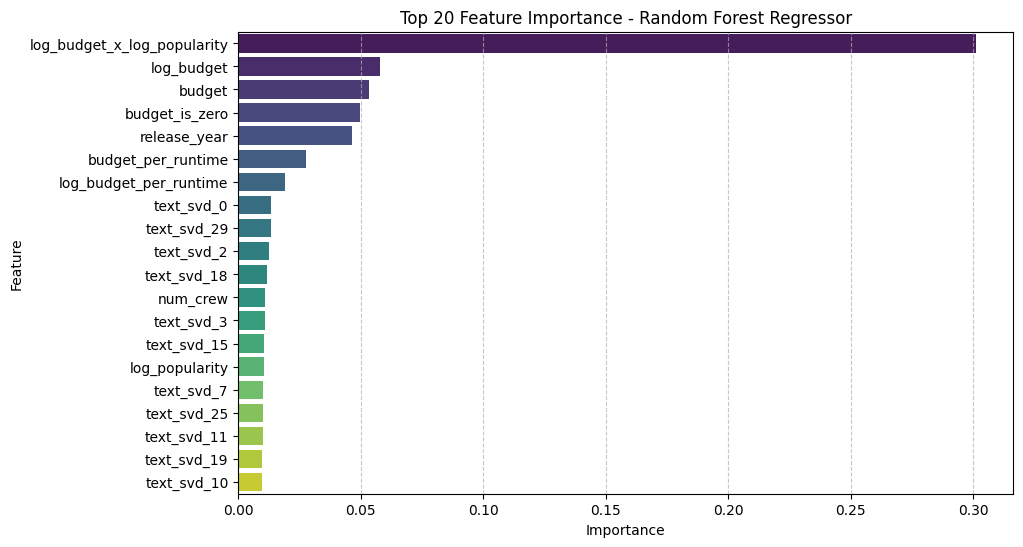

In [20]:
params_rf = {
    'model__n_estimators': [300, 500, 800],
    'model__max_depth': [10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', 0.6, 0.8, 1.0],
    'model__max_samples': [0.7, 0.8, 0.9]
}

rf_base = RandomForestRegressor(
    random_state=CONFIG['random_state'], 
    n_jobs=-1
)

search_rf = search_best_params(
    rf_base, 
    params_rf, 
    X_train, 
    y_train, 
    feature_pipeline
)

best_rf_pipeline = search_rf.best_estimator_

predict(best_rf_pipeline, 'Random Forest Regressor', X_test, y_test)

### 3.4 XGBoost Regressor

Best params for XGBRegressor:


,value
model__subsample,0.800
model__min_child_weight,3.000
model__max_depth,5.000
model__learning_rate,0.005
model__gamma,0.100
model__colsample_bytree,0.600


Model XGBoost R2: 0.5605, RMSLE: 1.9791


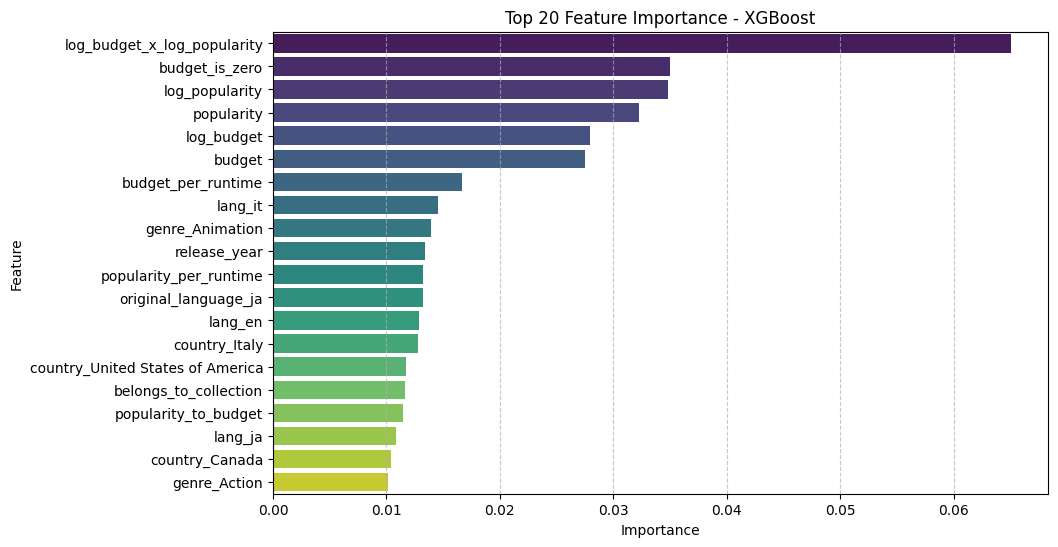

In [21]:
params_xgb = {
    'model__max_depth': [3, 4, 5, 6, 8],
    'model__learning_rate': [0.005, 0.01, 0.03, 0.05, 0.1],
    'model__subsample': [0.6, 0.7, 0.8, 0.9],   
    'model__colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'model__min_child_weight': [1, 3, 5],
    'model__gamma': [0, 0.1, 0.3],
}

xgb_base = XGBRegressor(
    n_estimators=CONFIG['n_estimators'],
    random_state=CONFIG['random_state'],
    n_jobs=-1,
    tree_method="hist"
)

search_xgb = search_best_params(xgb_base, params_xgb, X_train, y_train, feature_pipeline)

best_params_clean = {k.replace('model__', ''): v for k, v in search_xgb.best_params_.items()}
best_xgb_model = XGBRegressor(
    **best_params_clean,
    n_estimators=3000,
    early_stopping_rounds=50,
    random_state=CONFIG['random_state'],
    tree_method="hist"
)

best_xgb_pipeline = Pipeline([
    ('features', feature_pipeline),
    ('model', best_xgb_model)
])

X_val_clean_transformed = best_xgb_pipeline.named_steps['features'].fit(X_train).transform(X_val)
best_xgb_pipeline.fit(
    X_train, y_train,
    model__eval_set=[(X_val_clean_transformed, y_val)],
    model__verbose=False
)

predict(best_xgb_pipeline, 'XGBoost', X_test, y_test)

### 3.5 LightGBM Regressor

Best params for LGBMRegressor:


,value
model__subsample_freq,1.00
model__subsample,0.90
model__reg_lambda,0.10
model__reg_alpha,0.00
model__num_leaves,127.00
model__min_child_samples,20.00
model__max_depth,8.00
model__learning_rate,0.01
model__colsample_bytree,0.70


Model LightGBM R2: 0.5333, RMSLE: 2.0394


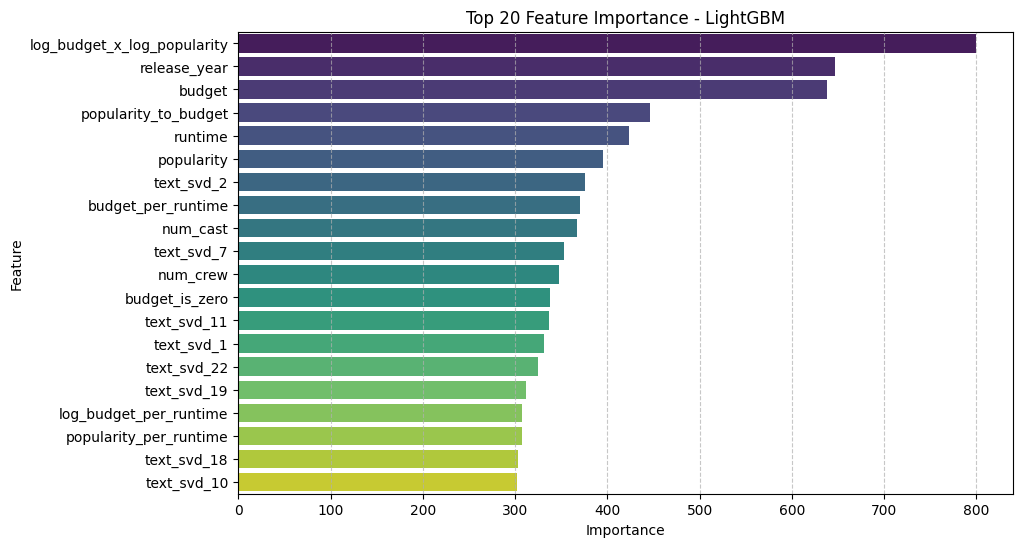

In [22]:
param_dist_lgb = {
    'model__num_leaves': [31, 63, 127],
    'model__max_depth': [5, 8, 10],
    'model__learning_rate': [0.01, 0.03, 0.05],
    'model__colsample_bytree': [0.7, 0.9],
    'model__subsample': [0.7, 0.9],
    'model__subsample_freq': [1],
    'model__min_child_samples': [20, 100],
    'model__reg_alpha': [0.0, 0.1],
    'model__reg_lambda': [0.0, 0.1]
}

lgb_base = LGBMRegressor(
    n_estimators=CONFIG['n_estimators'],
    random_state=CONFIG['random_state'],
    n_jobs=-1,
    boosting_type='gbdt',
    verbose=-1
)

search_lgb = search_best_params(
    lgb_base,
    param_dist_lgb,
    X_train,
    y_train,
    feature_pipeline
)

best_params_clean = {k.replace('model__', ''): v for k, v in search_lgb.best_params_.items()}
best_lgb_model = LGBMRegressor(
    **best_params_clean,
    n_estimators=3000,
    random_state=CONFIG['random_state'],
    n_jobs=-1,
    verbose=-1
)

best_lgb_pipeline = Pipeline([
    ('features', feature_pipeline),
    ('model', best_lgb_model)
])

X_val_clean_transformed = best_lgb_pipeline.named_steps['features'].fit(X_train).transform(X_val)
best_lgb_pipeline.fit(
    X_train,
    y_train,
    model__eval_set=[(X_val_clean_transformed, y_val)],
    model__eval_metric='rmse',
    model__callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
)

predict(best_lgb_pipeline, 'LightGBM', X_test, y_test)

### 3.6 CatBoost Regressor

Best params for CatBoostRegressor:


,value
model__learning_rate,0.05
model__l2_leaf_reg,9.00
model__depth,4.00


Model CatBoost R2: 0.5684, RMSLE: 1.9612


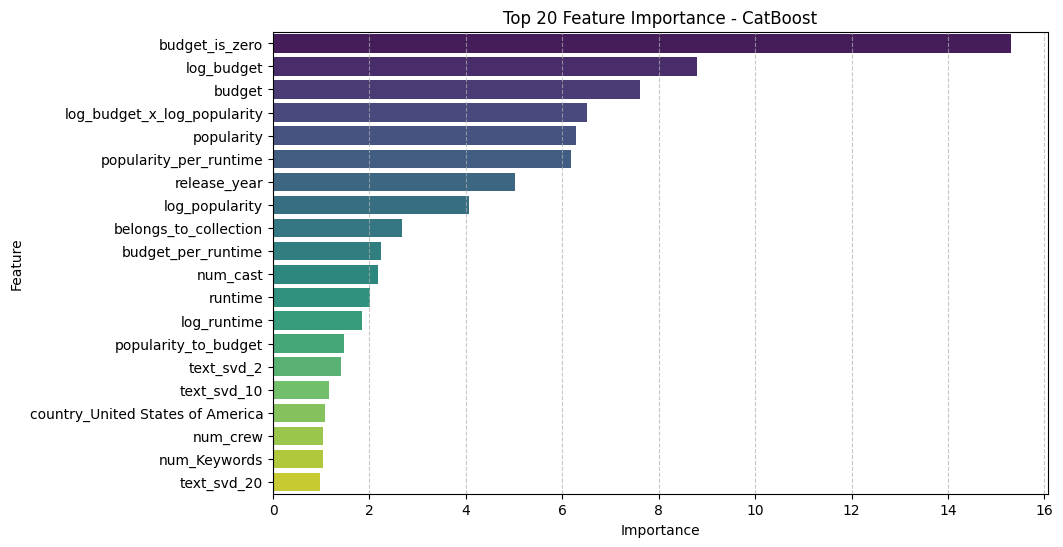

In [23]:
param_dist_cat = {
    'model__depth': [4, 6, 8],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__l2_leaf_reg': [1, 3, 5, 9]
}

cat_base = CatBoostRegressor(
    iterations=CONFIG['n_estimators'],                  
    bootstrap_type='Bernoulli',
    random_seed=CONFIG['random_state'],
    thread_count=-1,
    verbose=False
)

search_cat = search_best_params(
    cat_base,
    param_dist_cat,
    X_train,
    y_train,
    feature_pipeline
)

best_params_clean = {k.replace('model__', ''): v for k, v in search_cat.best_params_.items()}
best_cat_model = CatBoostRegressor(
    **best_params_clean,
    iterations=5000,
    bootstrap_type='Bernoulli',
    random_seed=CONFIG['random_state'],
    thread_count=-1,
    verbose=False
)

best_cat_pipeline = Pipeline([
    ('features', feature_pipeline),
    ('model', best_cat_model)
])

X_val_clean_transformed = best_cat_pipeline.named_steps['features'].fit(X_train).transform(X_val)

best_cat_pipeline.fit(
    X_train,
    y_train,
    model__eval_set=(X_val_clean_transformed, y_val),
    model__use_best_model=True,
    model__early_stopping_rounds=100,
    model__verbose=False
)

predict(best_cat_pipeline, 'CatBoost', X_test, y_test)

## 4. Results

,model,r2,rmsle
0,Baseline - Dummy Mean,-0.004118,2.991506
1,Baseline - Dummy Median,-0.028050,3.026946
2,Random Forest Regressor,0.529124,2.048571
3,XGBoost,0.560498,1.979147
4,LightGBM,0.533324,2.039413
5,CatBoost,0.568444,1.961175


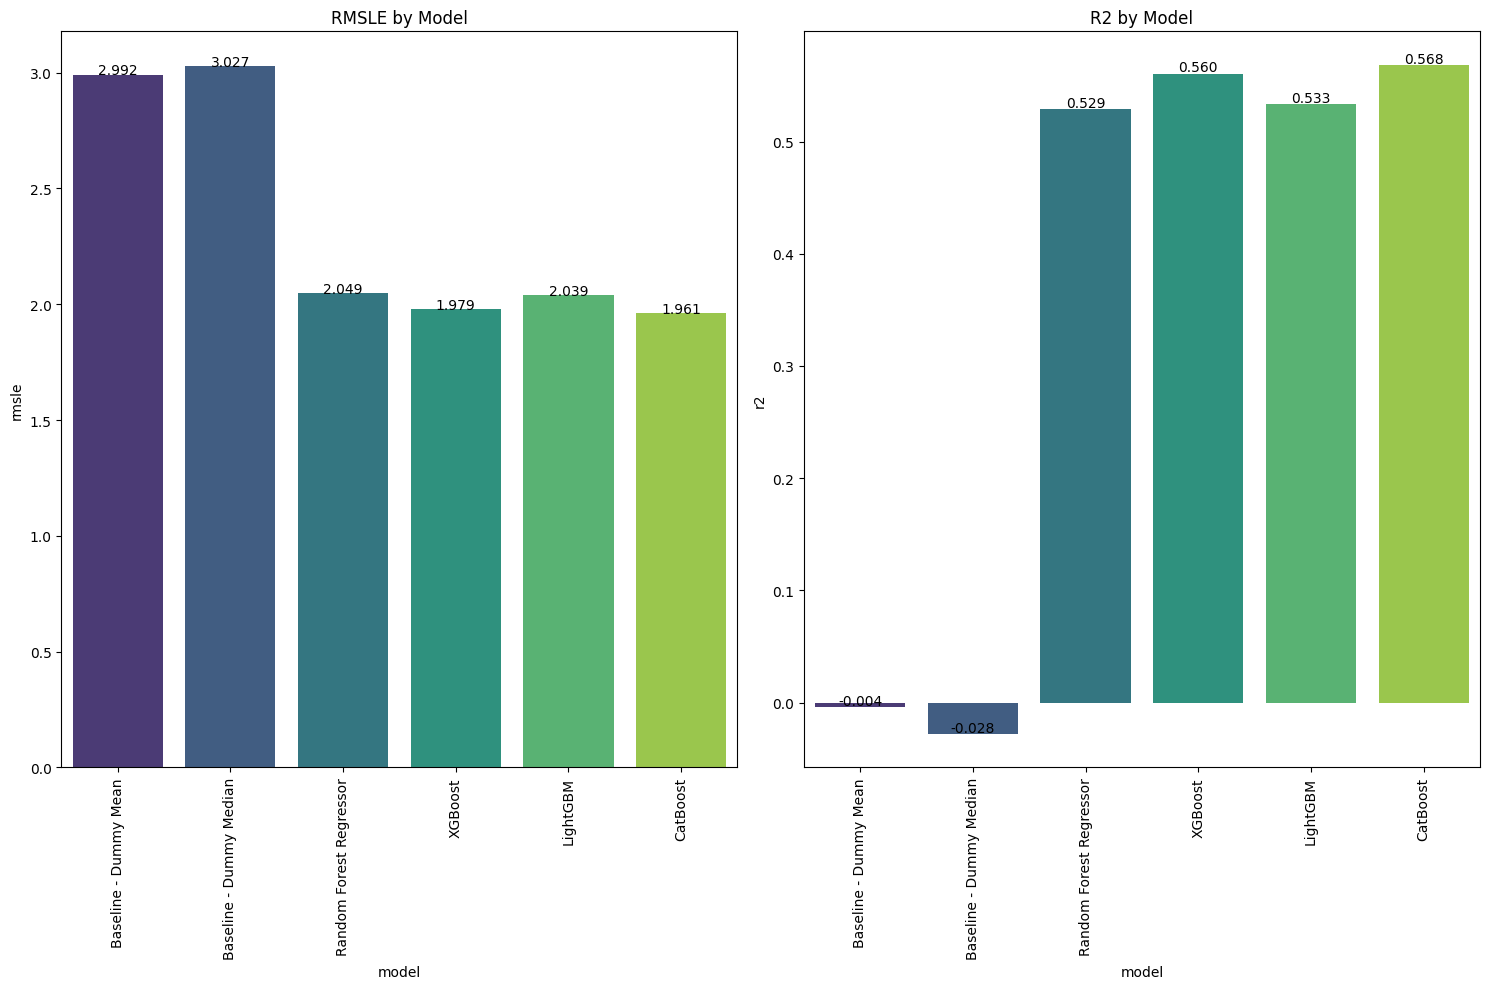

In [24]:
results = pd.DataFrame(results)
display(results)

plt.figure(figsize=(15, 10))
metrics = ['rmsle', 'r2']
for i in range(0, 2):
    plt.subplot(1, 2, i + 1)
    sns.barplot(x='model', y=metrics[i], data=results, palette='viridis', hue='model', legend=False)
    plt.title(f'{metrics[i].upper()} by Model')
    plt.xticks(rotation=90)
    for j, v in enumerate(results[metrics[i]]):
        plt.text(j, v + 0.002, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.show()

The evaluation of the models highlights a clear performance gap between the naive baselines and the tree-based ensemble methods. As expected, the dummy regressors fail to capture any meaningful patterns in the data, resulting in negative R-squared values and an RMSLE of approximately 3.0. This confirms that relying on simple central tendency metrics is entirely inadequate for this specific prediction task.

The shift to machine learning yields immediate and substantial improvements. The Random Forest architecture significantly reduces the error, establishing a solid benchmark with an RMSLE of 2.049 and an R-squared of 0.529. However, the gradient boosting algorithms consistently outperform this standard bagging approach. CatBoost proves to be the most robust model for the dataset, achieving the lowest overall prediction error (1.961) and explaining nearly 57% of the variance (R-squared 0.568). XGBoost follows very closely with highly competitive metrics, while LightGBM, despite easily beating the naive baselines, underperforms slightly compared to its boosting counterparts. Ultimately, these results justify the use of advanced boosting techniques, positioning CatBoost as the optimal algorithm for the final predictions.

## 5. Submission

In [25]:
best_model = best_cat_pipeline

test = pd.read_csv('../data/test.csv', index_col='id')

# There is a single movie without release date in the test set, so we will fill it with the release date found on https://www.imdb.com/it/title/tt0210130/
test.loc[3829, 'release_date'] = '03/20/01'
test = fix_dataset(test)

y_pred = best_model.predict(test)

submission = pd.DataFrame({
    'id': test.index,
    'revenue': np.expm1(y_pred)
})

submission.to_csv('../data/submission.csv', index=False)